In [2]:
!pip install treeple

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 20.2 MB/s eta 0:00:00a 0:00:01


In [3]:
# dependency libararies
import warnings
import os
import pickle
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import gc

# sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.svm import SVC

# treeple functions
import treeple
from treeple.ensemble import HonestForestClassifier, ObliqueRandomForestClassifier
from treeple.tree import ObliqueDecisionTreeClassifier
from treeple.stats import build_oob_forest

warnings.filterwarnings("ignore")


# default list for the results
from collections import defaultdict

In [4]:
import time
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import multivariate_normal
from scipy.stats import entropy
from scipy.stats import gamma
from sklearn import metrics


def Mix_Gaussian(
    mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
):
    """
    Generate a mixture of Gaussian dataset
    Args:
        mu_class0: mean of class 0
        mu_class1_1: mean of class 1 for the first component
        mu_class1_2: mean of class 1 for the second component
        sig: covariance matrix
        n: number of samples
        dim_info: number of informative features
        dim_total: total number of features
        mix: mixing ratio
        seed: random seed
    Returns:
        X: informative features
        X_all: all features
        y: labels
    """ 

    np.random.seed(seed)
    pdf_class0 = multivariate_normal(mean=mu_class0, cov=sig, allow_singular=True)
    pdf_class1_1 = [
        multivariate_normal(mean=mu_class1_1_i, cov=sig, allow_singular=True)
        for mu_class1_1_i in mu_class1_1
    ]
    pdf_class1_2 = [
        multivariate_normal(mean=mu_class1_2_i, cov=sig, allow_singular=True)
        for mu_class1_2_i in mu_class1_2
    ]

    n2 = [int(n * mix_i) for mix_i in mix]
    n1 = [n - n2_i for n2_i in n2]
    x_0 = [pdf_class0.rvs(size=n) for _ in range(dim_info)]
    x_1_1 = [pdf_class1_1[i].rvs(size=n1[i]) for i in range(dim_info)]
    x_1_2 = [pdf_class1_2[i].rvs(size=n2[i]) for i in range(dim_info)]
    y = np.array([0] * n + [1] * n).reshape(-1, 1)

    y = np.array([0] * n + [1] * n).reshape(-1, 1)
    X = np.zeros((2 * n, dim_info))
    for i in range(dim_info):
        X[:n, i] = x_0[i]
        X[n : (n + n1[i]), i] = x_1_1[i]
        X[(n + n1[i]) :, i] = x_1_2[i]
    X_noise = np.random.normal(0, 1, (2 * n, dim_total - dim_info))
    X_all = np.hstack((X, X_noise))

    return X, X_all, y


def Mix_Gaussian_Truth_Calculation(
    x, y, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
):
    pdf_class0 = multivariate_normal(mean=mu_class0, cov=sig, allow_singular=True)
    pdf_class1_1 = [
        multivariate_normal(mean=mu_class1_1_i, cov=sig, allow_singular=True)
        for mu_class1_1_i in mu_class1_1
    ]
    pdf_class1_2 = [
        multivariate_normal(mean=mu_class1_2_i, cov=sig, allow_singular=True)
        for mu_class1_2_i in mu_class1_2
    ]
    prior = [0.5, 0.5]

    p_x_given_class0 = 1
    p_x_given_class1 = 1
    for d in range(dim_info):
        X = x[:, d].reshape(-1, 1)
        p_x_given_class0 *= np.nan_to_num(pdf_class0.pdf(X))
        p_x_given_class1_1 = np.nan_to_num(pdf_class1_1[d].pdf(X))
        p_x_given_class1_2 = np.nan_to_num(pdf_class1_2[d].pdf(X))
        p_x_given_class1 *= (1 - mix[d]) * p_x_given_class1_1 + mix[
            d
        ] * p_x_given_class1_2
    p_x = prior[0] * p_x_given_class0 + prior[1] * p_x_given_class1
    pos_class0 = p_x_given_class0 * prior[0] / p_x
    pos_class1 = p_x_given_class1 * prior[1] / p_x
    posterior = np.hstack((pos_class0.reshape(-1, 1), pos_class1.reshape(-1, 1)))

    fpr, tpr, thresholds = metrics.roc_curve(
        y, posterior[:, 1], pos_label=1, drop_intermediate=False
    )
    tpr_s = np.max(tpr[fpr <= 0.02])
    return posterior, tpr_s


def Gaussian_sim_truth(n, ratio, dim_info, dim_total, seed):
    np.random.seed(seed)

    n1 = int(n * ratio)
    n0 = n - n1

    mu_0 = [0 for d in range(dim_info)]
    mu_1 = [1 / np.sqrt(d) for d in range(1, dim_info + 1)]

    sig_0 = [1 for d in range(dim_info)]
    sig_1 = [2 for d in range(dim_info)]

    pdf_class0 = [
        multivariate_normal(mean=mu_0[i], cov=sig_0[i], allow_singular=True)
        for i in range(dim_info)
    ]
    pdf_class1 = [
        multivariate_normal(mean=mu_1[i], cov=sig_1[i], allow_singular=True)
        for i in range(dim_info)
    ]

    x_0 = [pdf_class0[i].rvs(n0) for i in range(dim_info)]
    x_1 = [pdf_class1[i].rvs(n1) for i in range(dim_info)]
    y = np.array([0] * n0 + [1] * n1).reshape(-1, 1)
    X = np.zeros((n, dim_info))

    for i in range(dim_info):
        X[:n0, i] = x_0[i]
        X[n0:, i] = x_1[i]
    X_noise = np.random.normal(0, 1, (n, dim_total - dim_info))
    X_all = np.hstack((X, X_noise))

    pdf_class0 = [
        multivariate_normal(mean=mu_0[i], cov=sig_0[i], allow_singular=True)
        for i in range(dim_info)
    ]
    pdf_class1 = [
        multivariate_normal(mean=mu_1[i], cov=sig_1[i], allow_singular=True)
        for i in range(dim_info)
    ]
    prior = [1 - ratio, ratio]

    p_x_given_class0 = 1
    p_x_given_class1 = 1
    for d in range(dim_info):
        x = X[:, d].reshape(-1, 1)
        p_x_given_class0 *= np.nan_to_num(pdf_class0[d].pdf(x))
        p_x_given_class1 *= np.nan_to_num(pdf_class1[d].pdf(x))
    p_x = prior[0] * p_x_given_class0 + prior[1] * p_x_given_class1
    pos_class0 = p_x_given_class0 * prior[0] / p_x
    pos_class1 = p_x_given_class1 * prior[1] / p_x
    posterior = np.hstack((pos_class0.reshape(-1, 1), pos_class1.reshape(-1, 1)))

    fpr, tpr, thresholds = metrics.roc_curve(
        y, posterior[:, 1], pos_label=1, drop_intermediate=False
    )
    tpr_s = np.max(tpr[fpr <= 0.02])

    return X_all, y, posterior, tpr_s


def Calculate_MI(y_true, y_pred_proba):
    H_YX = np.mean(entropy(y_pred_proba, base=np.exp(1), axis=1))
    # empirical count of each class (n_classes)
    _, counts = np.unique(y_true, return_counts=True)
    H_Y = entropy(counts, base=np.exp(1))
    return H_Y - H_YX

[[0.5 0.5]
 [0.5 0.5]]
[[1.5 0. ]
 [1.5 0. ]]


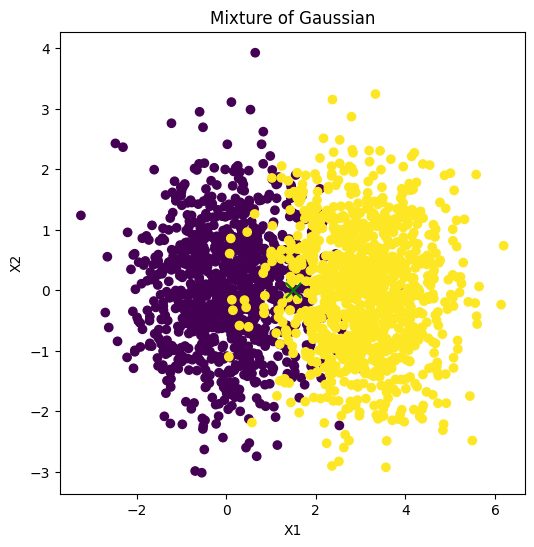

In [5]:
mu_class0 = [0]
mu_class1_1 = [3]
mu_class1_2 = [3]
sig = 1 
n = 1000
dim_info = 1
dim_total = 2
mix = [0.5, 0.5]
seed = 42
X, X_all, y = Mix_Gaussian(
    mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
)

# genetate a test dataset from the intersection of the two classes
# n_test = 100
# mu_class0 = [0]
# test_mu_class1_1 = [3/2, 0]
# test_mu_class1_2 = [3/2, 0]
# test_sig = 1
# test_X, test_X_all, test_y = Mix_Gaussian(
#     mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, n_test, dim_info, dim_total, mix, seed
# )
# # get only the sample with the label 1
# test_X = test_X[test_y.flatten()==1]
# test_X_all = test_X_all[test_y.flatten()==1]
# test_y = test_y[test_y.flatten()==1]
# print(test_X.shape, test_X_all.shape, test_y.shape)
X_test, y_test = [[3 / 2], [3 / 2]],[0, 1]
X_noise = np.random.normal(0, 1, (2, dim_total - dim_info))
X_test_all = np.array([[3 / 2, 0], [3 / 2, 0]])
y_test = np.array([0, 1]).reshape(-1, 1)

posterior, tpr_s = Mix_Gaussian_Truth_Calculation(
    X_test_all, y_test, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
)
print(posterior)

print(X_test_all)

# plot the test dataset on the same plot
plt.figure(figsize=(6, 6))
plt.scatter(X_all[:, 0], X_all[:, 1], c=y.flatten())
plt.scatter(X_test_all[0,0], X_test_all[0,1], c='green', marker='x', s=120)
plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Mixture of Gaussian")
plt.show()

Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]]
true_posterior_train [[0.91701429 0.08298571]
 [0.80835346 0.19164654]
 [0.99175357 0.00824643]
 ...
 [0.06256718 0.93743282]
 [0.00230832 0.99769168]
 [0.00153714 0.99846286]]
true_posterior_test [[0.5 0.5]
 [0.5 0.5]]


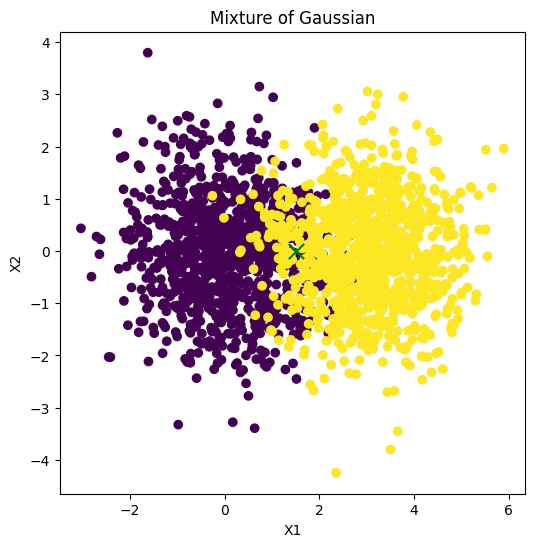

Running HonestForestClassifier
[[0.58593191 0.41406809]
 [0.58593191 0.41406809]]
Running RandomForestClassifier with isotonic
[0.76827506 0.23172494]
Running RandomForestClassifier with sigmoid
[0.79887812 0.20112188]
Running LogisticRegression with isotonic
[0.49359903 0.50640097]
Running LogisticRegression with sigmoid
[0.54780676 0.45219324]
Running SVC with isotonic
[0.60230706 0.39769294]
Running SVC with sigmoid
[0.67031326 0.32968674]
Running GradientBoostingClassifier with isotonic
[0.5932362 0.4067638]
Running GradientBoostingClassifier with sigmoid
[0.62300348 0.37699652]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.

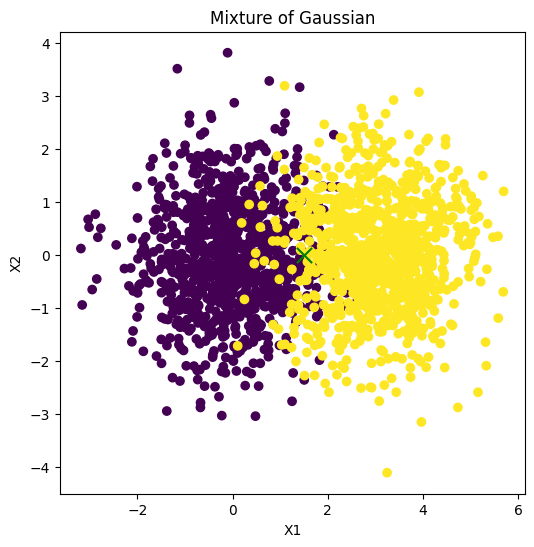

Running HonestForestClassifier
[[0.4382252 0.5617748]
 [0.4382252 0.5617748]]
Running RandomForestClassifier with isotonic
[0.37226898 0.62773102]
Running RandomForestClassifier with sigmoid
[0.29040147 0.70959853]
Running LogisticRegression with isotonic
[0.51111111 0.48888889]
Running LogisticRegression with sigmoid
[0.50763078 0.49236922]
Running SVC with isotonic
[0.55031288 0.44968712]
Running SVC with sigmoid
[0.66644089 0.33355911]
Running GradientBoostingClassifier with isotonic
[0.34597906 0.65402094]
Running GradientBoostingClassifier with sigmoid
[0.27321086 0.72678914]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  

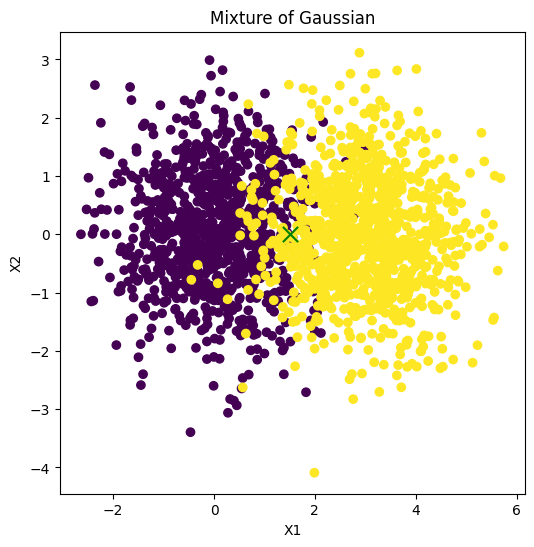

Running HonestForestClassifier
[[0.46185821 0.53814179]
 [0.46185821 0.53814179]]
Running RandomForestClassifier with isotonic
[0.39428571 0.60571429]
Running RandomForestClassifier with sigmoid
[0.28819372 0.71180628]
Running LogisticRegression with isotonic
[0.387773 0.612227]
Running LogisticRegression with sigmoid
[0.43419902 0.56580098]
Running SVC with isotonic
[0.29220779 0.70779221]
Running SVC with sigmoid
[0.19227466 0.80772534]
Running GradientBoostingClassifier with isotonic
[0.30865859 0.69134141]
Running GradientBoostingClassifier with sigmoid
[0.32778029 0.67221971]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  

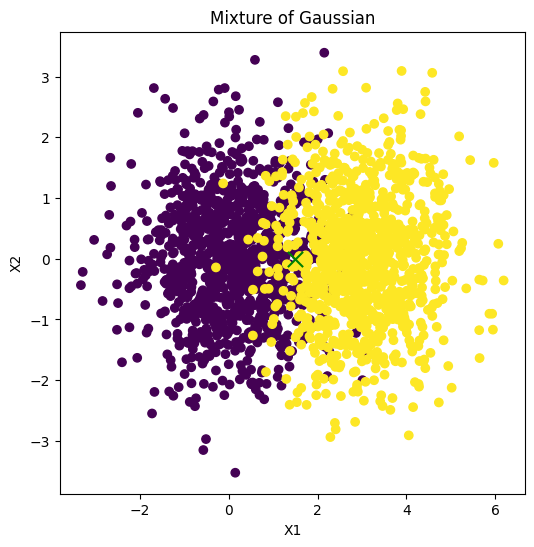

Running HonestForestClassifier
[[0.50140535 0.49859465]
 [0.50140535 0.49859465]]
Running RandomForestClassifier with isotonic
[0.34238095 0.65761905]
Running RandomForestClassifier with sigmoid
[0.41914465 0.58085535]
Running LogisticRegression with isotonic
[0.51131822 0.48868178]
Running LogisticRegression with sigmoid
[0.52031857 0.47968143]
Running SVC with isotonic
[0.43287449 0.56712551]
Running SVC with sigmoid
[0.47579745 0.52420255]
Running GradientBoostingClassifier with isotonic
[0.46338384 0.53661616]
Running GradientBoostingClassifier with sigmoid
[0.50353601 0.49646399]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  

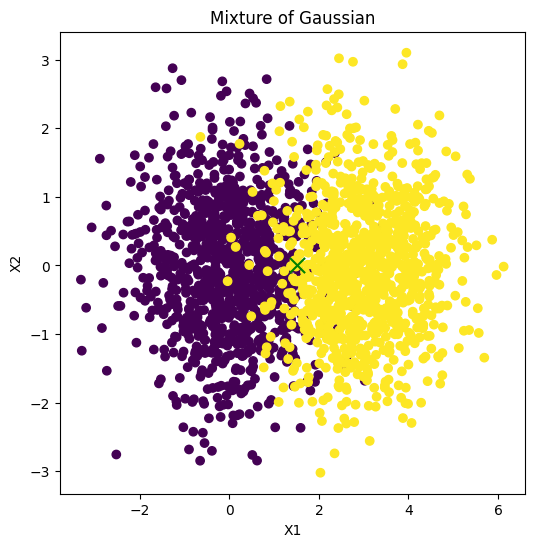

Running HonestForestClassifier
[[0.49064269 0.50935731]
 [0.49064269 0.50935731]]
Running RandomForestClassifier with isotonic
[0.44340979 0.55659021]
Running RandomForestClassifier with sigmoid
[0.32439571 0.67560429]
Running LogisticRegression with isotonic
[0.49582793 0.50417207]
Running LogisticRegression with sigmoid
[0.38792546 0.61207454]
Running SVC with isotonic
[0.60228118 0.39771882]
Running SVC with sigmoid
[0.63307736 0.36692264]
Running GradientBoostingClassifier with isotonic
[0.4831746 0.5168254]
Running GradientBoostingClassifier with sigmoid
[0.38069299 0.61930701]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.

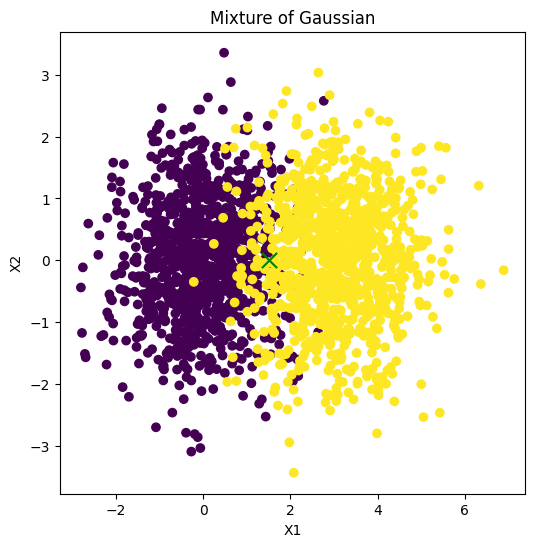

Running HonestForestClassifier
[[0.54355547 0.45644453]
 [0.54355547 0.45644453]]
Running RandomForestClassifier with isotonic
[0.70633859 0.29366141]
Running RandomForestClassifier with sigmoid
[0.73533702 0.26466298]
Running LogisticRegression with isotonic
[0.45370025 0.54629975]
Running LogisticRegression with sigmoid
[0.45028231 0.54971769]
Running SVC with isotonic
[0.27630592 0.72369408]
Running SVC with sigmoid
[0.23439013 0.76560987]
Running GradientBoostingClassifier with isotonic
[0.58672819 0.41327181]
Running GradientBoostingClassifier with sigmoid
[0.60771449 0.39228551]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  

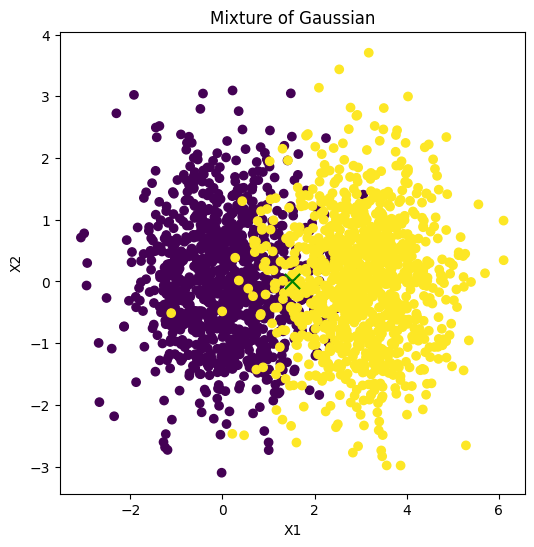

Running HonestForestClassifier
[[0.54971579 0.45028421]
 [0.54971579 0.45028421]]
Running RandomForestClassifier with isotonic
[0.60288366 0.39711634]
Running RandomForestClassifier with sigmoid
[0.56065789 0.43934211]
Running LogisticRegression with isotonic
[0.50300966 0.49699034]
Running LogisticRegression with sigmoid
[0.59103346 0.40896654]
Running SVC with isotonic
[0.50542781 0.49457219]
Running SVC with sigmoid
[0.44490058 0.55509942]
Running GradientBoostingClassifier with isotonic
[0.58579038 0.41420962]
Running GradientBoostingClassifier with sigmoid
[0.62364264 0.37635736]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  

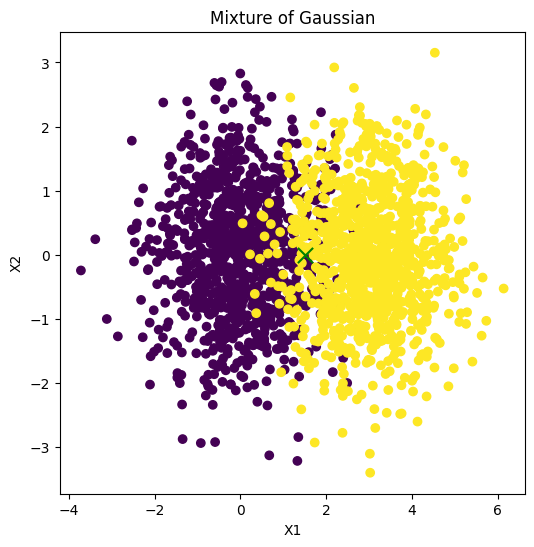

Running HonestForestClassifier
[[0.38482949 0.61517051]
 [0.38482949 0.61517051]]
Running RandomForestClassifier with isotonic
[0.1204023 0.8795977]
Running RandomForestClassifier with sigmoid
[0.1029813 0.8970187]
Running LogisticRegression with isotonic
[0.47390351 0.52609649]
Running LogisticRegression with sigmoid
[0.5367788 0.4632212]
Running SVC with isotonic
[0.57076948 0.42923052]
Running SVC with sigmoid
[0.67313003 0.32686997]
Running GradientBoostingClassifier with isotonic
[0.44858399 0.55141601]
Running GradientBoostingClassifier with sigmoid
[0.28207041 0.71792959]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.

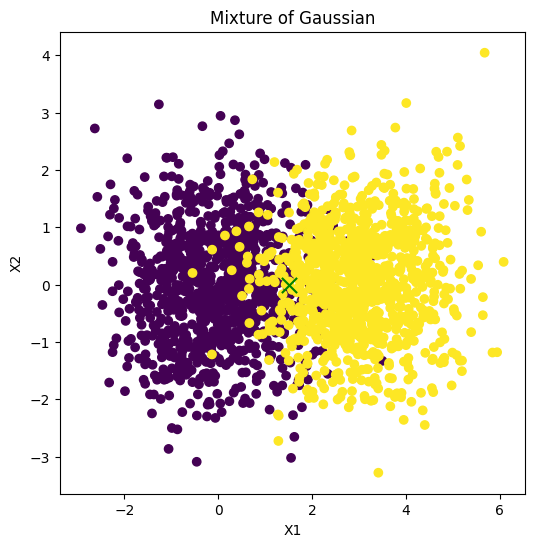

Running HonestForestClassifier
[[0.56162909 0.43837091]
 [0.56162909 0.43837091]]
Running RandomForestClassifier with isotonic
[0.61365079 0.38634921]
Running RandomForestClassifier with sigmoid
[0.71064462 0.28935538]
Running LogisticRegression with isotonic
[0.52539683 0.47460317]
Running LogisticRegression with sigmoid
[0.58271625 0.41728375]
Running SVC with isotonic
[0.30543672 0.69456328]
Running SVC with sigmoid
[0.28213247 0.71786753]
Running GradientBoostingClassifier with isotonic
[0.64470965 0.35529035]
Running GradientBoostingClassifier with sigmoid
[0.54991196 0.45008804]
Running experiment for dim: 50, n: 1000
X_test_all [[1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0. ]
 [1.5 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
  0.  

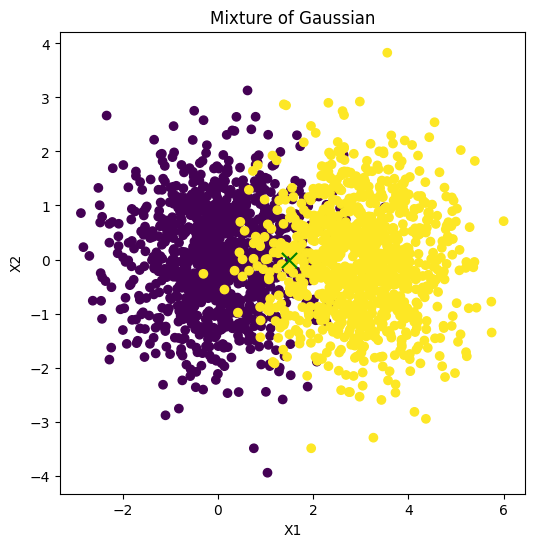

Running HonestForestClassifier
[[0.4236726 0.5763274]
 [0.4236726 0.5763274]]
Running RandomForestClassifier with isotonic
[0.33711152 0.66288848]
Running RandomForestClassifier with sigmoid
[0.27255246 0.72744754]
Running LogisticRegression with isotonic
[0.45105467 0.54894533]
Running LogisticRegression with sigmoid
[0.46230786 0.53769214]
Running SVC with isotonic
[0.48637619 0.51362381]
Running SVC with sigmoid
[0.49413265 0.50586735]
Running GradientBoostingClassifier with isotonic
[0.43264267 0.56735733]
Running GradientBoostingClassifier with sigmoid
[0.38686849 0.61313151]


In [ ]:
import json
import os
from collections import defaultdict
import time
from sklearn.exceptions import ConvergenceWarning
import test

# Suppress specific warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn.ensemble._forest")

CWD_DIR = !pwd
DIRECTORY = CWD_DIR[0] 
DATADIR = CWD_DIR[0] + "/ManuscriptFeatureMatrices/"
# DIRECTORY = "./ManuscriptFeatureMatrices/"
MODEL_DIR = CWD_DIR[0]
N_JOBS = 50
# N_EST = [100, 1000, 10_000,100_000] # 100_000
N_EST = 1000
MAX_SAMPLES = 1.6
RANDOM_STATE = np.random.randint(0, 1000)
N_TEST = 100
STAGE = True
RESULTS_FILE = f"Fig_1_1.json"
MAX_FEAURES = "sqrt"
n= 1000
HONEST_FRACTION = np.round(((n-1)/n)**n,2)
HONEST_PRIOR = "ignore"
HONEST_METHOD = "apply"
N_CV = 5

def log_results(model_name, method, dim, n, fit_time, accuracy, auc, f1, precision, recall, mi, posterior=None):
    log = {}
    log['model'] = model_name
    log['method'] = method
    log['dim'] = dim
    log['n'] = n
    log['fit_time'] = fit_time
    log['accuracy'] = accuracy
    log['auc'] = auc
    log['f1'] = f1
    log['precision'] = precision
    log['recall'] = recall
    log['mi'] = mi
    if posterior is not None:
        # save the posterior as a list
        log['posterior'] = posterior.tolist()
    file_path = os.path.join(MODEL_DIR, RESULTS_FILE)
    if RESULTS_FILE not in os.listdir(MODEL_DIR):
        # Save the kwargs as JSON
        with open(file_path, 'w') as json_file:
            json.dump([log], json_file, indent=4)  # Save as a list containing the first entry
    else:
        # Append the results to the file
        with open(file_path, 'r+') as json_file:
            try:
                data = json.load(json_file)
            except json.JSONDecodeError:
                data = []  # Initialize with an empty list if the file is empty or invalid
            data.append(log)
            json_file.seek(0)
            json.dump(data, json_file, indent=4)
    # return log

SPORF = HonestForestClassifier(
    n_estimators=N_EST,
    max_samples=MAX_SAMPLES,
    honest_fraction=HONEST_FRACTION,
    max_features=MAX_FEAURES,
    bootstrap=True,
    stratify=True,
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
    honest_prior=HONEST_PRIOR,
    honest_method=HONEST_METHOD,
    tree_estimator=ObliqueDecisionTreeClassifier(),
            )

# Set up Logistic Regression model calibrated with isotonic regression

RF = RandomForestClassifier(
    n_estimators=int(N_EST/N_CV),
    # max_samples=MAX_SAMPLES,
    # max_features=MAX_FEAURES,
    bootstrap=True,
    oob_score=True,
    random_state=RANDOM_STATE,
)

LR = LogisticRegression(
    penalty="l2",
    solver="liblinear",
    max_iter=1000,
    random_state=RANDOM_STATE,
)

# set up SVM classifier
SVM = SVC(
    probability=True,
    random_state=RANDOM_STATE,
)

# set up Gradient Boosting classifier
GB = GradientBoostingClassifier(
    n_estimators=int(N_EST/N_CV),
    random_state=RANDOM_STATE,
)

# Set up the experiment
# DIMS = [2, 10, 50, 100, 500, 1000]
DIMS = [50]
# SAMPLE_SIZE = [100, 1000, 5000, 10000, 50000, 100000]
SAMPLE_SIZE = [1000]
METHODS = ['isotonic', 'sigmoid']
N_REPEATS = 10
LOGS = []
for rep in range(N_REPEATS):
    RANDOM_STATE = np.random.randint(0, 1000)
    for dim in DIMS:
        for n in SAMPLE_SIZE:
            print(f"Running experiment for dim: {dim}, n: {n}")
            dim_info = 1
            mu_class0 = [0]
            mu_class1_1 = [3 for d in range(dim_info)]
            mu_class1_2 = [3 for d in range(dim_info)]
            sig = test_sig = 1
            dim_total = dim
            mix = [0.5, 0.5]
            seed = RANDOM_STATE
            X_train, X_train_all, y_train = Mix_Gaussian(
                mu_class0, mu_class1_1, mu_class1_2, sig, n, dim_info, dim_total, mix, seed
            )
            # print(X_train.shape, X_train_all.shape, y_train.shape)
            true_posterior_train, tpr_s = Mix_Gaussian_Truth_Calculation(
                X_train, y_train, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
            )
            # genetate a test dataset from the intersection of the two classes
            n_test = N_TEST
            n_test = 100
            mu_class0 = [0]
            test_mu_class1_1 = [x / 2 for x in mu_class1_1]
            test_mu_class1_2 = [x / 2 for x in mu_class1_2]
            test_sig = .5
            # X_test, X_test_all, y_test = Mix_Gaussian(
            #     mu_class0, test_mu_class1_1, test_mu_class1_2, test_sig, n_test, dim_info, dim_total, mix, seed
            # )
            # # get only the sample with the label 1
            # X_test = X_test[y_test.flatten()==1]
            # X_test_all = X_test_all[y_test.flatten()==1]
            # y_test = y_test[y_test.flatten()==1]
            X_test= np.array([3 / 2])
            X_test_all = np.hstack((test_mu_class1_1, [0 for x in range(dim_total - dim_info)]))
            # stack 2 samples for the test dataset
            X_test_all = np.vstack((X_test_all, X_test_all))
            y_test = np.array([0, 1])
            # test_sig = 1
            # print(X_test, y_test)
            # X_noise = np.random.normal(0, 1, dim_total - dim_info)
            # X_test_all = np.hstack((X_test, X_noise)).reshape(1,2)
            # # X_test_all = np.hstack(([3/2,0], [3/2,0])).reshape(-1,2)
            true_posterior_test, tpr_s = Mix_Gaussian_Truth_Calculation(
                X_test_all, y_test, mu_class0, mu_class1_1, mu_class1_2, sig, dim_info, mix
            )
            print( "X_test_all", X_test_all)
            print("true_posterior_train", true_posterior_train)
            print("true_posterior_test", true_posterior_test)
            # plot the test dataset on the same plot
            plt.figure(figsize=(6, 6))
            plt.scatter(X_train_all[:, 0], X_train_all[:, 1], c=y_train.flatten())
            plt.scatter(X_test_all[1,0], X_test_all[1,1], c='green', marker='x', s=120)
            plt.xlabel("X1")
            plt.ylabel("X2")
            plt.title("Mixture of Gaussian")
            plt.show()

            # run the experiment
            for model in [SPORF, RF, LR, SVM, GB]:
                model_name = model.__class__.__name__
                if model_name == "HonestForestClassifier":
                    print(f"Running {model_name}")
                    method = "HonestForest"
                    # start time
                    start_time = time.perf_counter()
                    # obtain tree level posteriors
                    fitted_model, tree_proba = build_oob_forest(model, X_train_all, y_train)
                    # posterior = np.nanmean(tree_proba, axis=0)#[:, 1]
                    # est.fit(X_sub, y_sub_label)
                    # calculate fitting time
                    end_time = time.perf_counter()
                    # calculate fitting time
                    fit_time = end_time - start_time
                    # predict on the test set
                    posterior = fitted_model.predict_proba(X_test_all)
                    # get the metrics and log the results
                    y_pred = np.argmax(posterior, axis=1)
                    y_true = y_test #.flatten()
                    # calculate the metrics
                    accuracy = accuracy_score(y_true, y_pred)
                    auc = roc_auc_score(y_true, posterior[:, 1])
                    f1 = f1_score(y_true, y_pred)
                    precision = precision_score(y_true, y_pred)
                    recall = recall_score(y_true, y_pred)
                    mi = Calculate_MI(y_true, posterior)
                    # log the results
                    log_results(model_name, method, dim, n, fit_time, accuracy, auc, f1, precision, recall, mi, posterior)
                    print(posterior)
                else:
                    # do 5-fold cross validation with CalibratedClassifierCV
                    for method in METHODS:
                        print(f"Running {model_name} with {method}")
                        cv = StratifiedKFold(n_splits=N_CV, shuffle=True, random_state=RANDOM_STATE)
                        # start time
                        start_time = time.perf_counter()
                        # fit the model
                        model = CalibratedClassifierCV(estimator=model, cv=cv, method=method, n_jobs=N_JOBS)
                        model.fit(X_train_all, y_train.flatten())
                        # calculate fitting time
                        end_time = time.perf_counter()
                        # calculate fitting time
                        fit_time = end_time - start_time
                        # predict on the test set
                        posterior = model.predict_proba(X_test_all)
                        # get the metrics and log the results
                        y_pred = np.argmax(posterior, axis=1)
                        y_true = y_test #.flatten()
                        # calculate the metrics
                        accuracy = accuracy_score(y_true, y_pred)
                        auc = roc_auc_score(y_true, posterior[:, 1])
                        f1 = f1_score(y_true, y_pred)
                        precision = precision_score(y_true, y_pred)
                        recall = recall_score(y_true, y_pred)
                        mi = Calculate_MI(y_true, posterior)
                        # log the results
                        log_results(model_name, method, dim, n, fit_time, accuracy, auc, f1, precision, recall, mi, posterior)
                        print(posterior[0])

